# Détection de Fraude Financière
## Analyse descriptive & modèles de classification

**Paramètres optimisés par RandomizedSearchCV sur les données.**
`class_weight` désactivé sur tous les modèles 

Structure :
1. Imports & installations
2. Chargement & exploration
3. Analyse descriptive
4. Valeurs manquantes
5. Pipeline préprocessing (sans data leakage)
6. Entraînement avec paramètres optimisés
7. Courbes ROC comparatives
8. Tableau de métriques & matrices de confusion
9. Importance des variables
10. Diagnostic du dataset & synthèse


## 0. Installations & imports

In [42]:
!pip install -q imblearn lightgbm


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [43]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.ensemble        import RandomForestClassifier
from sklearn.linear_model    import LogisticRegression
from sklearn.metrics         import (roc_curve, auc, precision_score, recall_score,
                                     f1_score, confusion_matrix, ConfusionMatrixDisplay)
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing   import LabelEncoder
from imblearn.over_sampling  import SMOTE
from imblearn.pipeline       import Pipeline as ImbPipeline
import lightgbm as lgb

np.random.seed(42)
sns.set_theme(style='whitegrid', palette='muted')
print("Imports OK")

Imports OK


## 1. Chargement & aperçu

In [44]:
data = pd.read_csv('Fraud Detection Dataset.csv')
print(f"Dimensions : {data.shape}")
data.head()

Dimensions : (51000, 12)


,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,T1,4174,1292.76,ATM Withdrawal,16.0,Tablet,San Francisco,0,119,13,Debit Card,0
1,T2,4507,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card,0
2,T3,1860,2395.02,ATM Withdrawal,NaN,Mobile,NaN,3,115,9,NaN,0
3,T4,2294,100.10,Bill Payment,15.0,Desktop,Chicago,4,3,4,UPI,0
4,T5,2130,1490.50,POS Payment,19.0,Mobile,San Francisco,2,57,7,Credit Card,0


In [45]:
data.info()
print()
print("Valeurs uniques :")
print(data.nunique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51000 entries, 0 to 50999
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Transaction_ID                    51000 non-null  object 
 1   User_ID                           51000 non-null  int64  
 2   Transaction_Amount                48480 non-null  float64
 3   Transaction_Type                  51000 non-null  object 
 4   Time_of_Transaction               48448 non-null  float64
 5   Device_Used                       48527 non-null  object 
 6   Location                          48453 non-null  object 
 7   Previous_Fraudulent_Transactions  51000 non-null  int64  
 8   Account_Age                       51000 non-null  int64  
 9   Number_of_Transactions_Last_24H   51000 non-null  int64  
 10  Payment_Method                    48531 non-null  object 
 11  Fraudulent                        51000 non-null  int64  
dtypes: f

            Nombre  Pourcentage (%)
Fraudulent                         
0            48490            95.08
1             2510             4.92


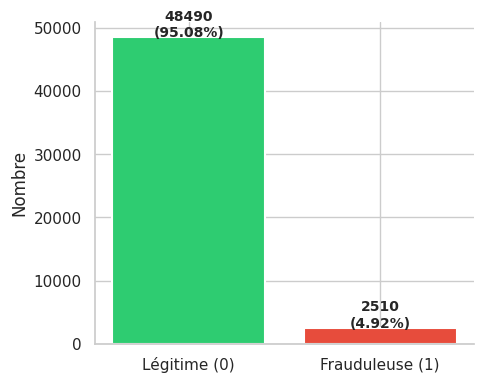

In [46]:
vc  = data['Fraudulent'].value_counts()
pct = data['Fraudulent'].value_counts(normalize=True).mul(100).round(2)
print(pd.DataFrame({'Nombre': vc, 'Pourcentage (%)': pct}))

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['Légitime (0)','Frauduleuse (1)'], vc.values,
       color=['#2ecc71','#e74c3c'], edgecolor='white', linewidth=1.5)
for i,(n,p) in enumerate(zip(vc.values, pct.values)):
    ax.text(i, n+100, f'{n}\n({p}%)', ha='center', fontsize=10, fontweight='bold')
#ax.set_title('Répartition des transactions', fontsize=13, fontweight='bold')
ax.set_ylabel('Nombre')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

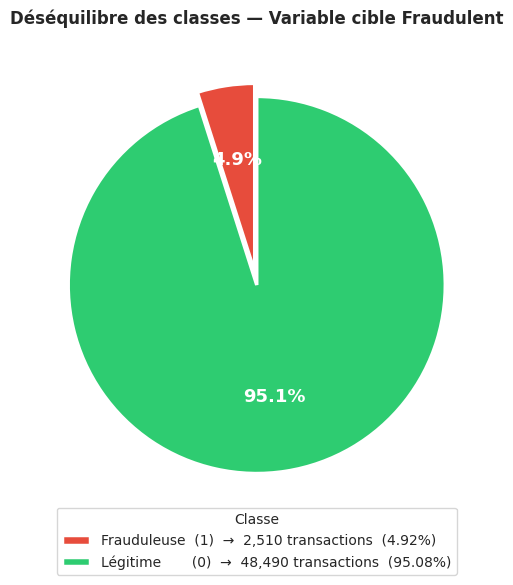

In [47]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv('Fraud Detection Dataset.csv')

# ── Calculs ───────────────────────────────────────────────────────────────────
vc  = data['Fraudulent'].value_counts()
pct = (data['Fraudulent'].value_counts(normalize=True) * 100).round(2)

n_legit  = vc[0]
n_fraud  = vc[1]
p_legit  = pct[0]
p_fraud  = pct[1]

sizes   = [n_fraud, n_legit]
colors  = ['#e74c3c', '#2ecc71']
explode = [0.07, 0.0]

# ── Figure ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))

wedges, _, autotexts = ax.pie(
    sizes,
    labels=None,
    colors=colors,
    autopct=lambda p: f'{p:.1f}%',
    startangle=90,
    explode=explode,
    pctdistance=0.6,
    wedgeprops=dict(edgecolor='white', linewidth=2.5),
)

for at in autotexts:
    at.set_fontsize(13)
    at.set_fontweight('bold')
    at.set_color('white')

# Légende
legend_labels = [
    f'Frauduleuse  (1)  →  {n_fraud:,} transactions  ({p_fraud}%)',
    f'Légitime       (0)  →  {n_legit:,} transactions  ({p_legit}%)',
]
ax.legend(wedges, legend_labels,
          title='Classe', title_fontsize=10,
          fontsize=10, loc='lower center',
          bbox_to_anchor=(0.5, -0.13), frameon=True)

ax.set_title('Déséquilibre des classes — Variable cible Fraudulent',
             fontsize=12, fontweight='bold', pad=18)

plt.tight_layout()
plt.show()

## 2. Analyse descriptive

In [48]:
data.describe().round(2)

,User_ID,Transaction_Amount,Time_of_Transaction,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Fraudulent
count,51000.00,48480.00,48448.00,51000.00,51000.00,51000.00,51000.00
mean,3005.11,2996.25,11.49,2.00,60.03,7.50,0.05
std,1153.12,5043.93,6.92,1.42,34.38,4.02,0.22
min,1000.00,5.03,0.00,0.00,1.00,1.00,0.00
25%,2007.00,1270.55,5.00,1.00,30.00,4.00,0.00
50%,2996.00,2524.10,12.00,2.00,60.00,7.00,0.00
75%,4006.00,3787.24,17.00,3.00,90.00,11.00,0.00
max,4999.00,49997.80,23.00,4.00,119.00,14.00,1.00


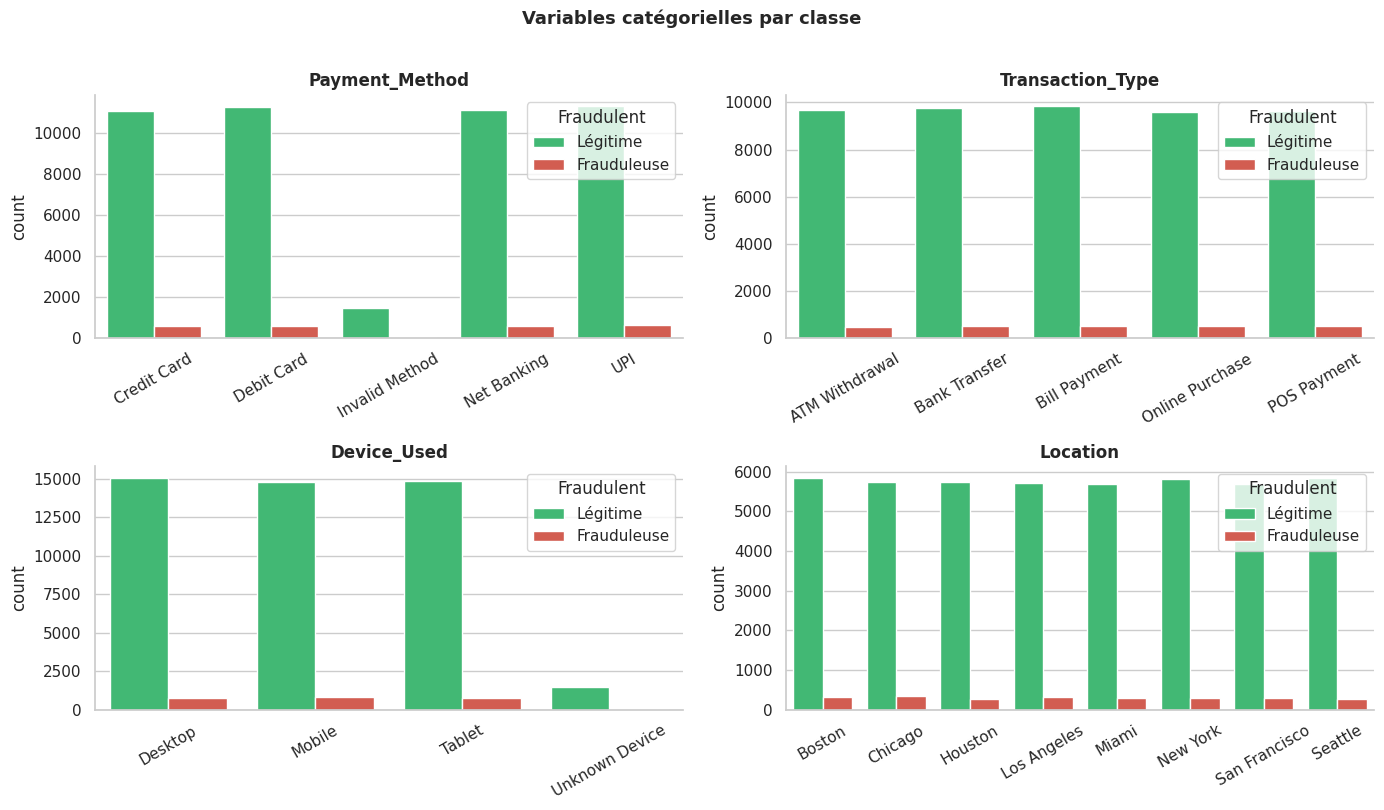

In [49]:
cat_cols = ['Payment_Method','Transaction_Type','Device_Used','Location']
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    df_plot = (data.groupby([col,'Fraudulent']).size().reset_index(name='count'))
    df_plot['Fraudulent'] = df_plot['Fraudulent'].map({0:'Légitime',1:'Frauduleuse'})
    sns.barplot(data=df_plot, x=col, y='count', hue='Fraudulent',
                palette={'Légitime':'#2ecc71','Frauduleuse':'#e74c3c'}, ax=axes[i])
    axes[i].set_title(col, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].set_xlabel('')
    axes[i].spines[['top','right']].set_visible(False)
plt.suptitle('Variables catégorielles par classe', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

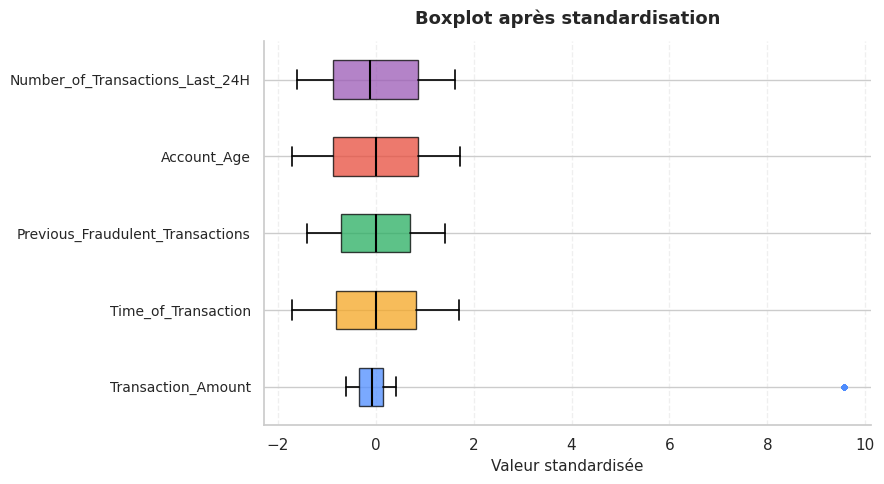

In [50]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.preprocessing import StandardScaler

data = pd.read_csv('Fraud Detection Dataset.csv')

# Variables numériques à afficher (sans les IDs et la cible)
num_cols = [
    'Transaction_Amount',
    'Time_of_Transaction',
    'Previous_Fraudulent_Transactions',
    'Account_Age',
    'Number_of_Transactions_Last_24H',
]

# Standardisation (mean=0, std=1)
scaler = StandardScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(data[num_cols].fillna(data[num_cols].mean())),
    columns=num_cols
)

# Palette de couleurs (une par variable, comme dans l'image)
COLORS = ['#4e8cff', '#f5a623', '#27AE60', '#e74c3c', '#9b59b6']

fig, ax = plt.subplots(figsize=(9, 5))

# Boxplot horizontal
bp = ax.boxplot(
    [df_scaled[col].dropna() for col in num_cols],
    vert=False,          # ← horizontal
    patch_artist=True,   # ← boîtes colorées
    widths=0.5,
    medianprops=dict(color='black', linewidth=1.5),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2),
    flierprops=dict(marker='o', markersize=3, alpha=0.4, linestyle='none'),
)

# Appliquer les couleurs
for patch, color in zip(bp['boxes'], COLORS):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

for flier, color in zip(bp['fliers'], COLORS):
    flier.set_markerfacecolor(color)
    flier.set_markeredgecolor(color)

# Étiquettes des axes
ax.set_yticks(range(1, len(num_cols) + 1))
ax.set_yticklabels(num_cols, fontsize=10)
ax.set_xlabel('Valeur standardisée', fontsize=11)
ax.set_title('Boxplot après standardisation', fontsize=13, fontweight='bold', pad=12)

# Légende
legend_patches = [mpatches.Patch(facecolor=c, alpha=0.75, label=col)
                  for c, col in zip(COLORS, num_cols)]
#ax.legend(handles=legend_patches, title='Variables', fontsize=8,
          #title_fontsize=9, loc='upper right', frameon=True)

ax.grid(True, axis='x', alpha=0.3, linestyle='--')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()



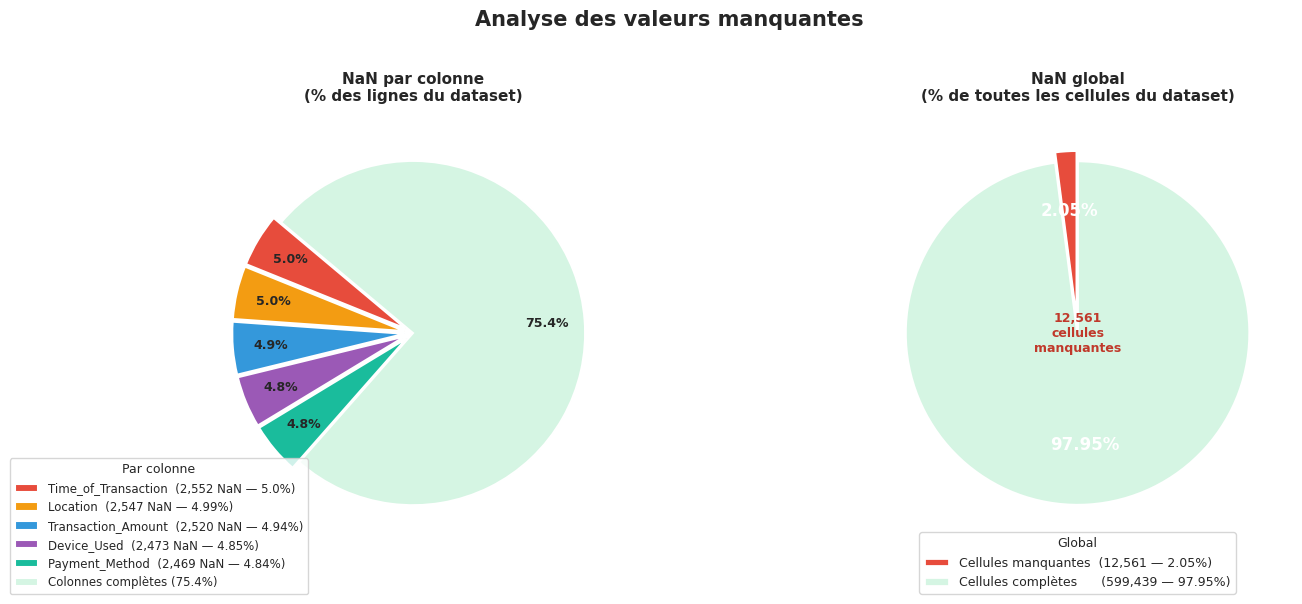

In [51]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv('Fraud Detection Dataset.csv')

# ── Calculs ───────────────────────────────────────────────────────────────────
missing     = data.isnull().sum()
missing     = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(data) * 100).round(2)

total_missing_pct = missing_pct.sum()
complete_pct      = 100 - total_missing_pct

# Global : total de cellules manquantes vs complètes sur tout le dataset
total_cells   = data.size
total_missing_cells   = data.isnull().sum().sum()
total_complete_cells  = total_cells - total_missing_cells
global_missing_pct    = round(total_missing_cells / total_cells * 100, 2)
global_complete_pct   = round(100 - global_missing_pct, 2)

COLORS_PIE = ['#e74c3c', '#f39c12', '#3498db', '#9b59b6', '#1abc9c', '#95a5a6']

# ── Figure avec 2 sous-graphiques côte à côte ─────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Analyse des valeurs manquantes', fontsize=15, fontweight='bold', y=1.01)

# ── Camembert gauche : NaN par colonne ───────────────────────────────────────
sizes_left  = list(missing_pct.values) + [complete_pct]
colors_left = COLORS_PIE[:len(missing_pct)] + ['#d5f5e3']
explode_left = [0.05] * len(missing_pct) + [0.0]

wedges1, _, autotexts1 = ax1.pie(
    sizes_left,
    labels=None,
    colors=colors_left,
    autopct=lambda p: f'{p:.1f}%' if p > 1 else '',
    startangle=140,
    explode=explode_left,
    pctdistance=0.78,
    wedgeprops=dict(edgecolor='white', linewidth=1.5),
)
for at in autotexts1:
    at.set_fontsize(9)
    at.set_fontweight('bold')

legend_labels1 = [f'{col}  ({missing[col]:,} NaN — {missing_pct[col]}%)'
                  for col in missing_pct.index]
legend_labels1 += [f'Colonnes complètes ({complete_pct:.1f}%)']

ax1.legend(wedges1, legend_labels1,
           title='Par colonne', title_fontsize=9,
           fontsize=8.5, loc='lower left',
           bbox_to_anchor=(-0.45, -0.12), frameon=True)
ax1.set_title('NaN par colonne\n(% des lignes du dataset)',
              fontsize=11, fontweight='bold', pad=12)

# ── Camembert droit : NaN global ─────────────────────────────────────────────
sizes_right  = [total_missing_cells, total_complete_cells]
colors_right = ['#e74c3c', '#d5f5e3']
explode_right = [0.06, 0.0]
labels_right  = [f'Manquantes\n{global_missing_pct}%',
                 f'Complètes\n{global_complete_pct}%']

wedges2, texts2, autotexts2 = ax2.pie(
    sizes_right,
    labels=None,
    colors=colors_right,
    autopct=lambda p: f'{p:.2f}%',
    startangle=90,
    explode=explode_right,
    pctdistance=0.65,
    wedgeprops=dict(edgecolor='white', linewidth=2),
    textprops=dict(fontsize=11),
)
for at in autotexts2:
    at.set_fontsize(12)
    at.set_fontweight('bold')
    at.set_color('white')

legend_labels2 = [
    f'Cellules manquantes  ({total_missing_cells:,} — {global_missing_pct}%)',
    f'Cellules complètes      ({total_complete_cells:,} — {global_complete_pct}%)',
]
ax2.legend(wedges2, legend_labels2,
           title='Global', title_fontsize=9,
           fontsize=9, loc='lower center',
           bbox_to_anchor=(0.5, -0.12), frameon=True)
ax2.set_title('NaN global\n(% de toutes les cellules du dataset)',
              fontsize=11, fontweight='bold', pad=12)

# Annotation centrale
ax2.text(0, 0, f'{total_missing_cells:,}\ncellules\nmanquantes',
         ha='center', va='center', fontsize=9, fontweight='bold', color='#c0392b')

plt.tight_layout()
plt.show()

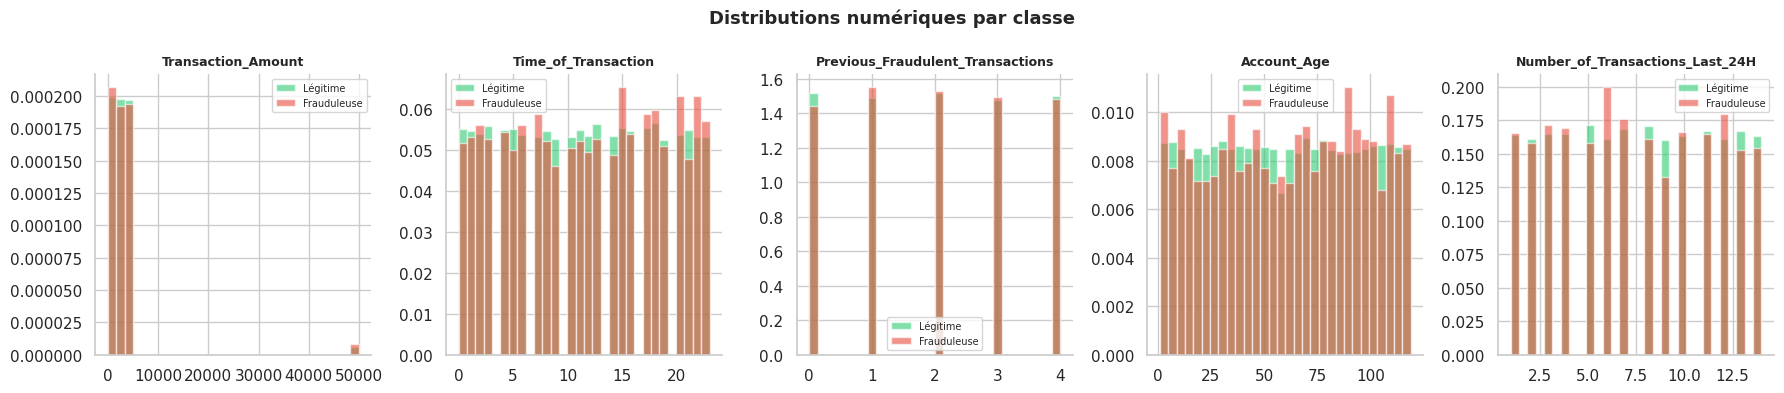

In [52]:
num_cols = ['Transaction_Amount','Time_of_Transaction',
            'Previous_Fraudulent_Transactions','Account_Age',
            'Number_of_Transactions_Last_24H']
fig, axes = plt.subplots(1, len(num_cols), figsize=(18, 4))
for ax, col in zip(axes, num_cols):
    for label, color in [(0,'#2ecc71'),(1,'#e74c3c')]:
        ax.hist(data[data['Fraudulent']==label][col].dropna(), bins=30,
                alpha=0.6, color=color, density=True,
                label='Légitime' if label==0 else 'Frauduleuse')
    ax.set_title(col, fontsize=9, fontweight='bold')
    ax.legend(fontsize=7)
    ax.spines[['top','right']].set_visible(False)
plt.suptitle('Distributions numériques par classe', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

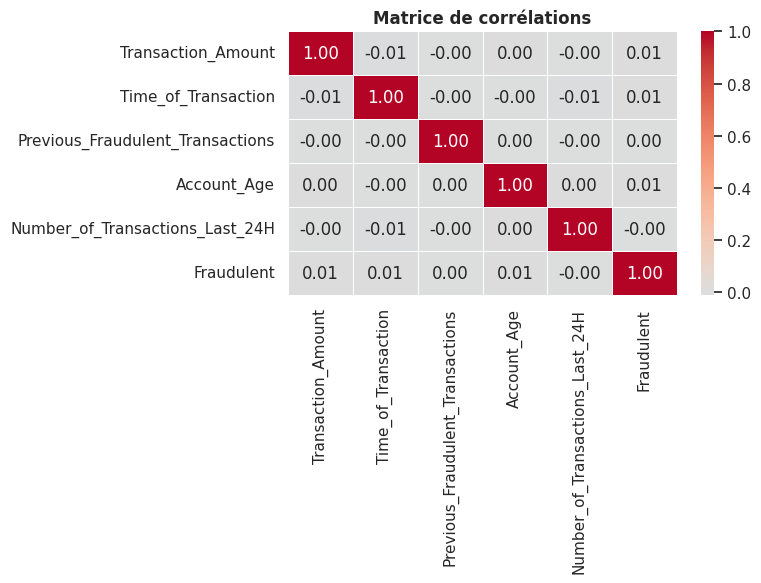

In [53]:
num_data = data.select_dtypes(include=['int64','float64']).drop(
    columns=['Transaction_ID','User_ID'], errors='ignore')
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(num_data.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax)
ax.set_title('Matrice de corrélations', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

## 3. Valeurs manquantes

In [54]:
missing = data.isnull().sum()
print(missing[missing > 0].to_frame('Manquantes')
      .assign(**{'%': (missing[missing>0]/len(data)*100).round(2)}))

                     Manquantes     %
Transaction_Amount         2520  4.94
Time_of_Transaction        2552  5.00
Device_Used                2473  4.85
Location                   2547  4.99
Payment_Method             2469  4.84


<img src="https://substack-post-media.s3.amazonaws.com/public/images/730d9518-707f-4263-8925-9679ace2d78f_2102x2327.png" width="1000" height="500"/>


# **Little test**
* https://statinferentielle.fr/test-little-mcar/#:~:text=Hypoth%C3%A8ses%20du%20test%20de%20Little,elles%20sont%20MAR%20ou%20MNAR).

> ## `Hypothèses du test Little`
> Hypothèse nulle (H₀)  : Les données manquantes sont MCAR.
>
> Hypothèse alternative (H₁): Les données ne sont pas MCAR (elles sont MAR ou MNAR).

In [55]:
dat = data.drop(columns=['Transaction_ID', 'User_ID'])

num_dat = data.select_dtypes(include=['float64', 'int64'])  # Pour les colonnes numériques
cat_dat = data.select_dtypes(include=['object'])  # Pour les colonnes catégorielles


In [56]:
!pip install pyampute
from pyampute.exploration.mcar_statistical_tests import MCARTest



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [57]:
from pyampute.exploration.mcar_statistical_tests import MCARTest
mt = MCARTest(method="little")
mt.little_mcar_test(num_data)


np.float64(0.4473061470781854)

## 4. Pipeline préprocessing — sans data leakage

- `Transaction_ID` / `User_ID` supprimés (identifiants, pas des features)
- Split **avant** imputation & encodage
- Imputation & LabelEncoder fittés sur `X_train` uniquement
- `X_test` / `y_test` **gelés** après le split — jamais touchés par SMOTE


In [58]:
# ═══════════════════════════════════════════════════════════════════
# PIPELINE UNIQUE — exécuter une seule fois
# Produit : X_train, y_train, X_test, y_test
# ═══════════════════════════════════════════════════════════════════

df = pd.read_csv('Fraud Detection Dataset.csv')
df = df.drop(columns=[c for c in ['Transaction_ID','User_ID'] if c in df.columns])

y = df['Fraudulent']
X = df.drop(columns=['Fraudulent'])

# ② Split AVANT tout preprocessing — X_test / y_test GELÉS ici
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train : {X_train.shape} | Test : {X_test.shape}")
print(f"Fraude train : {y_train.mean():.2%} | Fraude test : {y_test.mean():.2%}")

# Imputation conditionnelle (fit sur train, appliquée au test)
for col in X_train.columns:
    if X_train[col].isnull().any() or X_test[col].isnull().any():
        if X_train[col].dtype in ['int64','float64']:
            means = X_train.groupby(y_train)[col].mean()
            X_train[col] = X_train[col].fillna(y_train.map(means))
            X_test[col]  = X_test[col].fillna(y_test.map(means).fillna(means.mean()))
        else:
            modes = X_train.groupby(y_train)[col].agg(lambda s: s.mode().iloc[0])
            X_train[col] = X_train[col].fillna(y_train.map(modes))
            X_test[col]  = X_test[col].fillna(y_test.map(modes).fillna(modes.iloc[0]))

# Encodage catégoriel (fit sur train uniquement)
encoders = {}
for col in X_train.select_dtypes(include='object').columns:
    le = LabelEncoder().fit(X_train[col].astype(str))
    X_train[col] = le.transform(X_train[col].astype(str))
    known = set(le.classes_)
    X_test[col]  = X_test[col].astype(str).apply(
        lambda v: int(le.transform([v])[0]) if v in known else 0)
    encoders[col] = le

print(f"NaN restants — train: {X_train.isnull().sum().sum()} | test: {X_test.isnull().sum().sum()}")
print("✓ X_test / y_test gelés — ne seront plus jamais modifiés")

Train : (40800, 9) | Test : (10200, 9)
Fraude train : 4.92% | Fraude test : 4.92%
NaN restants — train: 0 | test: 0
✓ X_test / y_test gelés — ne seront plus jamais modifiés


## 5. Modèles avec paramètres optimisés

> Paramètres trouvés par **RandomizedSearchCV** sur les données.
> `class_weight` désactivé sur tous les modèles après test comparatif
>
> - **Sans SMOTE** : modèles standards, pas de compensation du déséquilibre
> - **Avec SMOTE** : `ImbPipeline(SMOTE → modèle)` — SMOTE à l'intérieur des folds


In [59]:
# ═══════════════════════════════════════════════════════════════════
# PARAMÈTRES OPTIMISÉS — class_weight désactivé
# ═══════════════════════════════════════════════════════════════════

# ── Sans SMOTE ───────────────────────────────────────────────────────────────
rf_no = RandomForestClassifier(
    n_estimators=200, max_depth=10, min_samples_split=5,
    min_samples_leaf=2, max_features='sqrt',
    random_state=42, n_jobs=-1)


lgb_no = lgb.LGBMClassifier(
    n_estimators=400, learning_rate=0.01, num_leaves=63,
    max_depth=10, min_child_samples=20,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, verbose=-1)


lr_no = LogisticRegression(
    C=0.001, penalty='l2', solver='liblinear',
    max_iter=2000, random_state=42)


# ── Avec SMOTE ───────────────────────────────────────────────────────────────
# SMOTE : sampling_strategy=0.25 → minorité = 25% de la majorité (≈20% du total)
# SMOTE est dans ImbPipeline → appliqué uniquement sur les folds d'entraînement
# X_test n'est jamais touché

pipe_rf_sm = ImbPipeline([
    ('smote', SMOTE(sampling_strategy=0.25, random_state=42)),
    ('rf',    RandomForestClassifier(
                n_estimators=200, max_depth=20, min_samples_split=2,
                min_samples_leaf=1, max_features='sqrt',
                random_state=42, n_jobs=-1))
])


pipe_lgb_sm = ImbPipeline([
    ('smote', SMOTE(sampling_strategy=0.25, random_state=42)),
    ('lgb',   lgb.LGBMClassifier(
                n_estimators=200, learning_rate=0.05, num_leaves=31,
                max_depth=-1, min_child_samples=10,
                random_state=42, verbose=-1))
])


pipe_lr_sm = ImbPipeline([
    ('smote', SMOTE(sampling_strategy=0.25, random_state=42)),
    ('lr',    LogisticRegression(
                C=0.01, penalty='l1', solver='liblinear',
                max_iter=2000, random_state=42))
])


print("Modèles configurés ✓")

Modèles configurés ✓


## 6. Entraînement & évaluation sur X_test

In [60]:
def evaluate(model, name, protocol):
    model.fit(X_train, y_train)
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, ths = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    yi = np.argmax(tpr - fpr)
    tau = ths[yi]
    y_pred = (y_prob >= tau).astype(int)
    return {
        'Protocole': protocol, 'Modèle': name,
        'AUC':       round(roc_auc, 3),
        'Recall':    round(recall_score(y_test, y_pred), 3),
        'Précision': round(precision_score(y_test, y_pred, zero_division=0), 3),
        'F1':        round(f1_score(y_test, y_pred, zero_division=0), 3),
        'Youden':    round(tpr[yi] - fpr[yi], 3),
        'Seuil τ*':  round(float(tau), 3),
        '_model': model, '_y_prob': y_prob, '_fpr': fpr, '_tpr': tpr,
    }

all_results = [
    evaluate(rf_no,       'Random Forest',          'Sans SMOTE'),
    evaluate(lgb_no,      'LightGBM',               'Sans SMOTE'),
    evaluate(lr_no,       'Régression Logistique',   'Sans SMOTE'),
    evaluate(pipe_rf_sm,  'Random Forest',           'Avec SMOTE'),
    evaluate(pipe_lgb_sm, 'LightGBM',               'Avec SMOTE'),
    evaluate(pipe_lr_sm,  'Régression Logistique',   'Avec SMOTE'),
]

for r in all_results:
    print(f"[{r['Protocole']}] {r['Modèle']:28s} → "
          f"AUC={r['AUC']:.3f} | Recall={r['Recall']:.3f} | F1={r['F1']:.3f}")

[Sans SMOTE] Random Forest                → AUC=0.611 | Recall=0.277 | F1=0.145
[Sans SMOTE] LightGBM                     → AUC=0.615 | Recall=0.610 | F1=0.117
[Sans SMOTE] Régression Logistique        → AUC=0.530 | Recall=0.707 | F1=0.098
[Avec SMOTE] Random Forest                → AUC=0.555 | Recall=0.508 | F1=0.107
[Avec SMOTE] LightGBM                     → AUC=0.598 | Recall=0.825 | F1=0.109
[Avec SMOTE] Régression Logistique        → AUC=0.526 | Recall=0.797 | F1=0.099


## 7. Courbes ROC comparatives

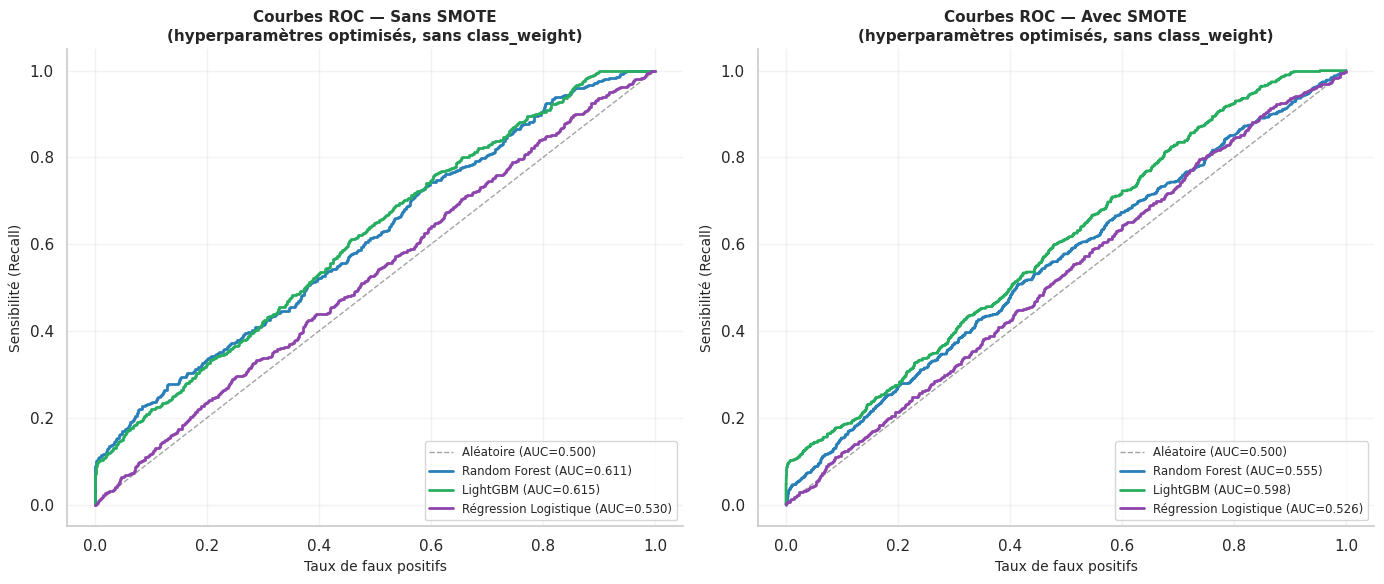

In [61]:
COLORS = {
    'Random Forest':         '#2980B9',
    'LightGBM':              '#27AE60',
    'Régression Logistique': '#8E44AD',
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, pname in zip(axes, ['Sans SMOTE','Avec SMOTE']):
    ax.plot([0,1],[0,1],'k--', alpha=0.4, linewidth=1, label='Aléatoire (AUC=0.500)')
    for r in [res for res in all_results if res['Protocole'] == pname]:
        ax.plot(r['_fpr'], r['_tpr'], color=COLORS[r['Modèle']], linewidth=2,
                label=f"{r['Modèle']} (AUC={r['AUC']:.3f})")
    ax.set_xlabel('Taux de faux positifs', fontsize=10)
    ax.set_ylabel('Sensibilité (Recall)', fontsize=10)
    ax.set_title(f'Courbes ROC — {pname}\n(hyperparamètres optimisés, sans class_weight)',
                 fontsize=11, fontweight='bold')
    ax.legend(fontsize=8.5, loc='lower right', frameon=True)
    ax.grid(True, alpha=0.25)
    ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

## 8. Tableau de métriques & matrices de confusion

In [62]:
cols = ['Protocole','Modèle','AUC','Recall','Précision','F1','Youden','Seuil τ*']
df_results = pd.DataFrame(all_results)[cols]

def highlight_max(s):
    return ['background-color:#d5f5e3;font-weight:bold' if v==s.max() else '' for v in s]

display(df_results.style
        .apply(highlight_max, subset=['AUC','Recall','Précision','F1','Youden'])
        .format({c:'{:.3f}' for c in ['AUC','Recall','Précision','F1','Youden','Seuil τ*']})
        .set_caption('Sans SMOTE vs Avec SMOTE — paramètres optimisés, sans class_weight'))

,Protocole,Modèle,AUC,Recall,Précision,F1,Youden,Seuil τ*
0,Sans SMOTE,Random Forest,0.611,0.277,0.099,0.145,0.146,0.064
1,Sans SMOTE,LightGBM,0.615,0.610,0.065,0.117,0.155,0.044
2,Sans SMOTE,Régression Logistique,0.530,0.707,0.053,0.098,0.051,0.039
3,Avec SMOTE,Random Forest,0.555,0.508,0.060,0.107,0.094,0.127
4,Avec SMOTE,LightGBM,0.598,0.825,0.058,0.109,0.136,0.051
5,Avec SMOTE,Régression Logistique,0.526,0.797,0.053,0.099,0.060,0.138


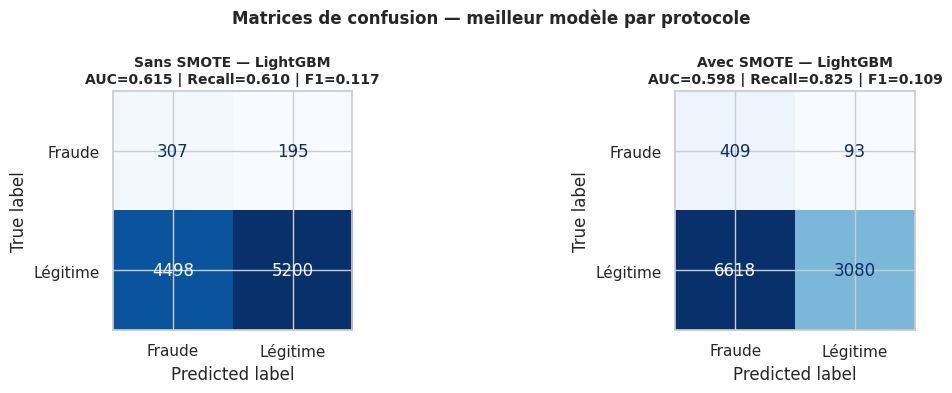

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, pname in zip(axes, ['Sans SMOTE','Avec SMOTE']):
    best_p = max([r for r in all_results if r['Protocole']==pname], key=lambda r: r['AUC'])
    y_pred = (best_p['_y_prob'] >= best_p['Seuil τ*']).astype(int)
    ConfusionMatrixDisplay(
        confusion_matrix(y_test, y_pred, labels=[1,0]),
        display_labels=['Fraude','Légitime']
    ).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f"{pname} — {best_p['Modèle']}\n"
                 f"AUC={best_p['AUC']:.3f} | Recall={best_p['Recall']:.3f} | F1={best_p['F1']:.3f}",
                 fontsize=10, fontweight='bold')
plt.suptitle('Matrices de confusion — meilleur modèle par protocole',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

## 9. Importance des variables

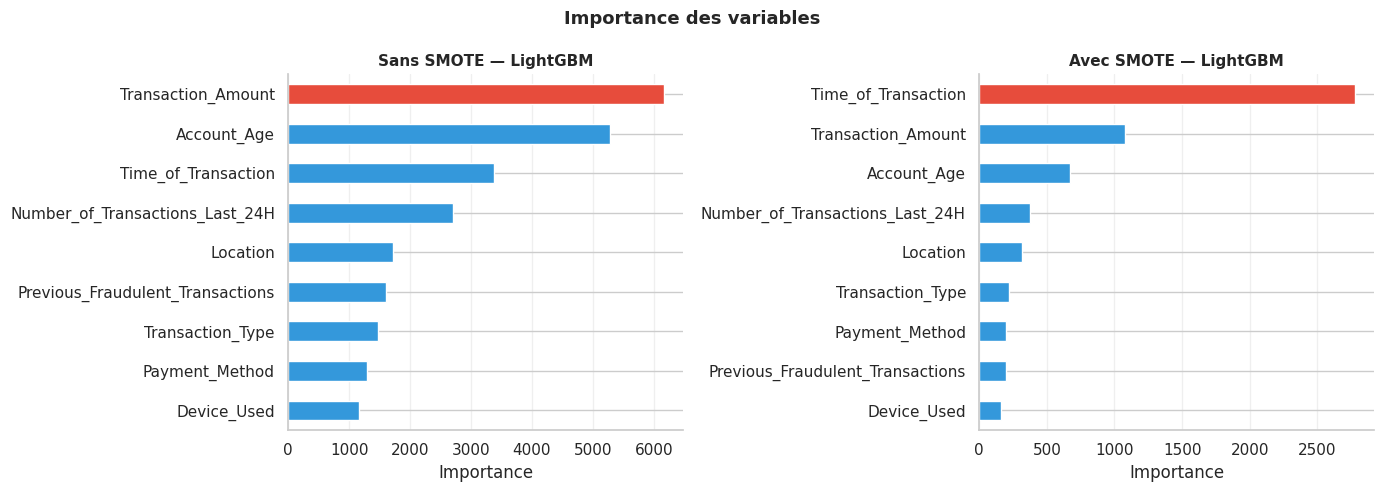

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, pname in zip(axes, ['Sans SMOTE','Avec SMOTE']):
    best_p = max([r for r in all_results if r['Protocole']==pname], key=lambda r: r['AUC'])
    m = best_p['_model']
    est = m[-1] if hasattr(m, '__getitem__') else m
    if hasattr(est, 'feature_importances_'):
        imp = est.feature_importances_
    elif hasattr(est, 'coef_'):
        imp = np.abs(est.coef_[0])
    else:
        continue
    feat_imp = pd.Series(imp, index=X_train.columns).sort_values()
    colors = ['#e74c3c' if v==feat_imp.max() else '#3498db' for v in feat_imp.values]
    feat_imp.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
    ax.set_title(f'{pname} — {best_p["Modèle"]}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Importance')
    ax.spines[['top','right']].set_visible(False)
    ax.grid(True, axis='x', alpha=0.3)
plt.suptitle('Importance des variables', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## 10. Diagnostic du dataset & synthèse

In [65]:
print("=== Corrélation des features avec la cible ===")
corr = X_train.corrwith(y_train).abs().sort_values(ascending=False)
print(corr.round(4))
print()
print(f"{'Feature':42s} | {'Légit':>8} | {'Fraude':>8} | {'|Diff|':>8}")
print('-' * 72)
for col in X_train.columns:
    m0 = X_train[col][y_train==0].mean()
    m1 = X_train[col][y_train==1].mean()
    print(f"{col:42s} | {m0:8.3f} | {m1:8.3f} | {abs(m1-m0):8.3f}")

=== Corrélation des features avec la cible ===
Location                            0.0262
Transaction_Type                    0.0130
Time_of_Transaction                 0.0118
Device_Used                         0.0118
Account_Age                         0.0076
Transaction_Amount                  0.0074
Number_of_Transactions_Last_24H     0.0047
Previous_Fraudulent_Transactions    0.0027
Payment_Method                      0.0006
dtype: float64

Feature                                    |    Légit |   Fraude |   |Diff|
------------------------------------------------------------------------
Transaction_Amount                         | 2986.081 | 3154.141 |  168.061
Transaction_Type                           |    1.994 |    2.078 |    0.084
Time_of_Transaction                        |   11.473 |   11.842 |    0.369
Device_Used                                |    1.009 |    1.057 |    0.048
Location                                   |    3.580 |    3.305 |    0.274
Previous_Fraudulent_T

In [67]:
print("=" * 65)
print("SYNTHÈSE FINALE")
print("=" * 65)
df_r = pd.DataFrame(all_results)[['Protocole','Modèle','AUC','Recall','F1']]
for pname in ['Sans SMOTE','Avec SMOTE']:
    sub = df_r[df_r['Protocole']==pname].drop(columns='Protocole')
    print(f"\n── {pname} ──")
    print(sub.to_string(index=False))

best = max(all_results, key=lambda r: r['AUC'])
print(f"\n🏆 Meilleure config : {best['Modèle']} ({best['Protocole']})")
print(f"   AUC={best['AUC']:.3f} | Recall={best['Recall']:.3f} | F1={best['F1']:.3f} | τ*={best['Seuil τ*']:.3f}")



SYNTHÈSE FINALE

── Sans SMOTE ──
               Modèle   AUC  Recall    F1
        Random Forest 0.611   0.277 0.145
             LightGBM 0.615   0.610 0.117
Régression Logistique 0.530   0.707 0.098

── Avec SMOTE ──
               Modèle   AUC  Recall    F1
        Random Forest 0.555   0.508 0.107
             LightGBM 0.598   0.825 0.109
Régression Logistique 0.526   0.797 0.099

🏆 Meilleure config : LightGBM (Sans SMOTE)
   AUC=0.615 | Recall=0.610 | F1=0.117 | τ*=0.044
